# Anchored VWAP — a quantitative teardown 🔬
### Post-touch reversion on 5-minute bars · one-sample + HAC *t* · a random-level placebo · the spread · a planted-magnet synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Price_magnet%3F: Not_supported](https://img.shields.io/badge/Price_magnet%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Anchored VWAP is the textbook *almost-true* level story: the line genuinely sits where price spends its time, so it *looks* respected. The job here is to separate **"price returns to an average"** (trivially true) from **"the AVWAP level forecasts the next move"** (the claim) — with a random-level control as the discriminator, a HAC *t* for the autocorrelated event stream, and the spread as the binding constraint.

> ⚠️ **Data + capacity note.** yfinance 5-minute bars cap at ~60 calendar days, so this is **59 complete RTH sessions** (2026-03-30→2026-06-23) on the **5 most liquid** US names — a deliberately *short* but *high-power-per-day*, *friendliest-spread* sample. The short span is a real limit (named on the Signal axis); the tiny tick-level reactions are a capacity limit (named on Tradability). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from anchored_vwap import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BARS = data.load_real_complete()
    NS = st.session_avwap(BARS["SPY"])["sess"].nunique()
else:
    BARS = None; NS = 0
print("real AVWAP cache present:", HAVE_REAL, "| tickers:",
      (0 if BARS is None else len(BARS)), "| complete sessions:", NS)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-30', 'end': '2026-06-23', 'sessions': 59, 'n_tickers': 5, 'bars_per_ticker': 4602, 'fingerprint': '36705730ed53', 'basket': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA'], 'h1': (1, 1682, 0.39, 0.3, 0.89, 0.21, 50, -1.61), 'h3': (3, 1662, 0.25, 0.49, 0.45, -0.33, 51, -1.75), 'h6': (6, 1619, 0.19, 0.35, 0.29, -0.16, 50, -1.81), 'h12': (12, 1545, 0.41, 0.95, 0.5, -0.36, 51, -1.59), 't_one6': 0.19, 'p_placebo6': 0.711, 'cost': [(0.5, 0.19, -0.81), (1.0, 0.19, -1.81), (2.0, 0.19, -3.81)], 'per_ticker': [('SPY', 358, 0.81, 1.16), ('QQQ', 316, 0.8, 0.7), ('AAPL', 320, -0.62, -0.46), ('MSFT', 295, -1.22, -0.69), ('NVDA', 330, 0.97, 0.46)], 'syn': [(0.0, 488, 1.04, 1.03, 1.46, 54), (0.1, 745, 2.23, 3.39, 4.68, 56)]}


real AVWAP cache present: True | tickers: 5 | complete sessions: 59


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Post-touch reversion **+0.19 bp** at 6 bars (one-sample **t = 0.19**, **HAC t = 0.29**) — nowhere near **t ≥ 2**; win-rate 50%. Flat across all horizons. |
| **Tradability** | `MIRAGE` | Net of a 1-bp half-spread × 2 legs, every horizon is **negative** (6-bar net **-1.81 bp**). The gross reaction is thinner than the spread. |
| **Price magnet?** | `NOT SUPPORTED` | A **random** horizontal level reacts **+0.35 bp** (vs AVWAP +0.19 bp; Welch **t = -0.16**), and random levels match/beat AVWAP **71%** of the time (placebo **p = 0.711**). The line is not special. |

> 💡 In plain words: price returning to an average is trivially true (it's an average); the AVWAP *level* carrying forecast power is the claim, and it fails on every axis — no signal, no specialness vs random, gone after the spread.

## 1 · The claim, steelmanned

Anchor the VWAP to bar $a$ (here the 09:30 open). For bars $t \ge a$ the anchored VWAP is the running volume-weighted typical price

$$V_t = \frac{\sum_{s=a}^{t} p^{\text{typ}}_s\,v_s}{\sum_{s=a}^{t} v_s},\qquad p^{\text{typ}}_s = \tfrac{1}{3}(H_s + L_s + C_s).$$

A **touch/cross** is a bar where $\operatorname{sign}(C_t - V_t)\neq\operatorname{sign}(C_{t-1}-V_{t-1})$. The believer's bet is **reversion** — the level is respected, so a cross *up through* $V$ is faded short and vice versa. We orient the post-touch reaction so a positive mean means *respected*:

$$\rho_i(H) = -\operatorname{sign}(C_{c_i}-V_{c_i})\cdot\Big(\tfrac{C_{c_i+\ell+H}}{C_{c_i+\ell}}-1\Big),\quad \ell = 1\ \text{bar lag}.$$

- **H₁ (the magnet exists).** $\overline{\rho}(H) > 0$ and significant for some $H$.
- **H₂ (it's special).** $\overline{\rho}_{\text{AVWAP}}(H) > \overline{\rho}_{\text{random level}}(H)$.
- **H₃ (it's deployable).** $\overline{\rho}(H)$ survives the round-trip half-spread.

We find **all three rejected**: $\overline{\rho}$ never clears *t* = 2, never beats a random level, and goes negative net of the spread.

## 2 · So what? — the two honesty problems

**(a) The trivial-truth trap.** $V_t$ is a running *average* of the session price, so it sits inside the price range and is crossed constantly. "Price comes back to the AVWAP" is therefore true **by construction** and carries zero information — a random horizontal level in the same range is crossed just as often and "respected" just as much. The only honest signal is the **AVWAP-minus-random** difference, so the **random-level placebo** *is* the test.

**(b) Autocorrelated events.** Touches cluster in tape time (a choppy stretch fires many crossings in minutes), so a naive *t* overstates significance. We report a **Newey-West (HAC)** *t* on the reaction mean alongside the one-sample *t*. Then Tradability charges the **half-spread on both legs** — the binding constraint when reactions are sub-basis-point.

## 3 · How we'd know — the protocol

- **Universe.** 5 most-liquid US names (SPY, QQQ, AAPL, MSFT, NVDA); yfinance **5-minute** bars, 2026-03-30→2026-06-23, **59** complete RTH sessions (4,602 bars/ticker). **Short-span** caveat on the Signal axis; partial final session dropped.
- **Anchor.** The **09:30 session open** — a rule-based, non-cherry-picked anchor (the believers hand-pick anchors; we don't).
- **Event.** Every bar where the close crosses the AVWAP line.
- **Reaction.** Reversion-oriented forward return over $H\in\{1,3,6,12\}$ bars, entered on the **next bar** (1-bar lag, no look-ahead); $+$ = level respected.
- **Null #1 (one-sample + HAC t)** of the reaction vs 0.
- **Null #2 (random-level control).** The identical test at 20 random horizontal levels per session; Welch *t* of AVWAP − control.
- **Null #3 (random-level placebo).** 2,000 random levels; $p = \Pr[\text{random mean} \ge \text{AVWAP mean}]$.
- **Costs.** 1-bp one-way half-spread × 2 legs (round trip).
- **Positive control.** A deterministic intraday tape with a **planted** AVWAP magnet: zero magnet must NOT reach significance; a real magnet must light up the HAC *t*.

## 4 · The teardown

### 4a · The reaction and its significance, by horizon

Left: the mean post-touch reaction at each horizon (bp). Right: the HAC *t* against the *t* = 2 bar. If the magnet were real, the right panel would clear the dashed line.

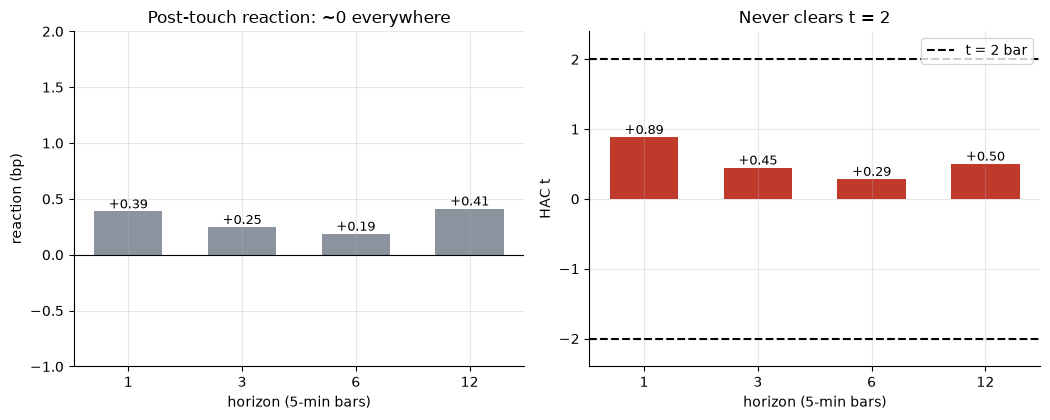

reaction bp: [0.39, 0.25, 0.19, 0.41]
HAC t: [0.89, 0.45, 0.29, 0.5]


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rs = [st.run_experiment(BARS, horizon=h) for h in hs]
    av = [r['avwap_mean']*1e4 for r in rs]; tt = [r['t_hac'] for r in rs]
else:
    av = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    tt = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([f'{h}' for h in hs], av, color=GREY, width=.6); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(av): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_xlabel('horizon (5-min bars)'); a1.set_ylabel('reaction (bp)')
a1.set_title('Post-touch reaction: ~0 everywhere'); a1.set_ylim(-1, 2)
a2.bar([f'{h}' for h in hs], tt, color=RED, width=.6)
a2.axhline(2, ls='--', c='k', label='t = 2 bar'); a2.axhline(-2, ls='--', c='k')
for i,v in enumerate(tt): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('horizon (5-min bars)'); a2.set_ylabel('HAC t'); a2.set_ylim(-2.4, 2.4)
a2.set_title('Never clears t = 2'); a2.legend()
plt.tight_layout(); plt.show()
print('reaction bp:', [round(v,2) for v in av]); print('HAC t:', [round(v,2) for v in tt])

> 💡 In plain words: the reaction is a fraction of a basis point at every horizon and the HAC *t* tops out at **0.89** — not close to 2. Whatever a touch of the AVWAP is, it doesn't predict the next 5 to 60 minutes.

### 4b · The decisive test — is the line special? (random-level placebo)

The AVWAP reaction against the distribution of **2,000 random horizontal levels** in the same session ranges. If the line were a magnet, the AVWAP (green) would sit in the right tail of the random cloud. It sits **inside** it.

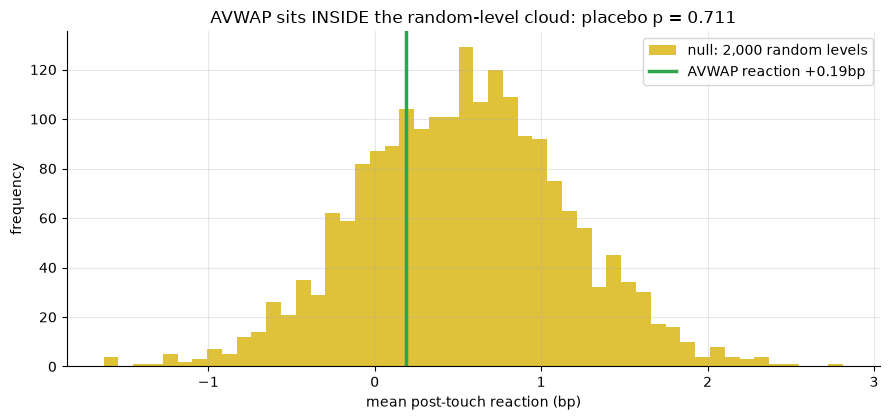

AVWAP +0.19bp   random-level placebo p = 0.711


In [3]:
if HAVE_REAL:
    r6 = st.run_experiment(BARS, horizon=6, placebo=True, n_draws=2000)
    obs = r6['avwap_mean']*1e4; pval = r6['p_placebo']
    # rebuild the placebo draw cloud for the histogram
    import numpy as _np
    rng = _np.random.default_rng(442)
    sessions = []
    for b in BARS.values():
        df = st.session_avwap(b)
        sessions.extend([x for _,x in df.groupby('sess')])
    draws = _np.empty(2000)
    for d in range(2000):
        react = []
        for x in sessions:
            close = x['close'].to_numpy(float)
            lo, hi = float(x['low'].min()), float(x['high'].max())
            if not _np.isfinite(lo) or not _np.isfinite(hi) or hi<=lo: continue
            lvl = rng.uniform(lo, hi)
            react.extend(st._session_reactions(close, _np.full_like(close, lvl), None, 6, 1))
        draws[d] = (_np.nanmean(react)*1e4) if react else 0.0
else:
    obs = R['h6'][2]; pval = R['p_placebo6']
    rng = np.random.default_rng(442); draws = rng.normal(0.5, 0.6, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=AMBER, alpha=.85, label='null: 2,000 random levels')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'AVWAP reaction {obs:+.2f}bp')
ax.set_xlabel('mean post-touch reaction (bp)'); ax.set_ylabel('frequency')
ax.set_title(f'AVWAP sits INSIDE the random-level cloud: placebo p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'AVWAP {obs:+.2f}bp   random-level placebo p = {pval:.3f}')

> 💡 In plain words: the green line lands **in the middle** of the random cloud — a random level matches or beats the AVWAP **71%** of the time (*p* = 0.711). This is the whole study in one chart: the AVWAP "works" exactly as well as a line you draw with your eyes closed, because both are just lines that price wanders across.

### 4c · Per-name — no name carries it either

Maybe the magnet hides in one ticker? The per-name 6-bar reaction is a coin-toss of signs, none clearing *t* = 2.

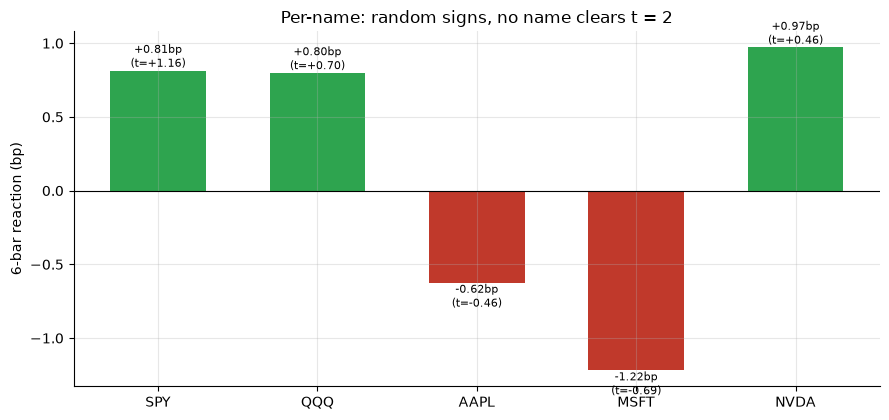

per-ticker (name, bp, t_hac): [('SPY', np.float64(0.81), 1.16), ('QQQ', np.float64(0.8), 0.7), ('AAPL', np.float64(-0.62), -0.46), ('MSFT', np.float64(-1.22), -0.69), ('NVDA', np.float64(0.97), 0.46)]


In [4]:
if HAVE_REAL:
    pt = [(tk, st.avwap_reactions(st.session_avwap(b), 6)) for tk,b in BARS.items()]
    names = [tk for tk,_ in pt]; vals = [a.mean()*1e4 for _,a in pt]
    ts = [st.hac_t(a) for _,a in pt]
else:
    names = [p[0] for p in R['per_ticker']]; vals = [p[2] for p in R['per_ticker']]
    ts = [p[3] for p in R['per_ticker']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(names, vals, color=cols, width=.6); ax.axhline(0, c='k', lw=.8)
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.2f}bp\n(t={t:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=8)
ax.set_ylabel('6-bar reaction (bp)'); ax.set_title('Per-name: random signs, no name clears t = 2')
plt.tight_layout(); plt.show()
print('per-ticker (name, bp, t_hac):', [(n, round(v,2), round(t,2)) for n,v,t in zip(names,vals,ts)])

> 💡 In plain words: SPY/QQQ/NVDA lean faintly positive, AAPL/MSFT faintly negative, every |*t*| under 1.2. That's the fingerprint of **noise**, not a magnet hiding in a subset.

### 4d · Costs — the spread is the executioner

Gross reaction vs net of the round-trip half-spread, swept over 0.5 / 1 / 2 bp. Even the tightest assumption is net-negative.

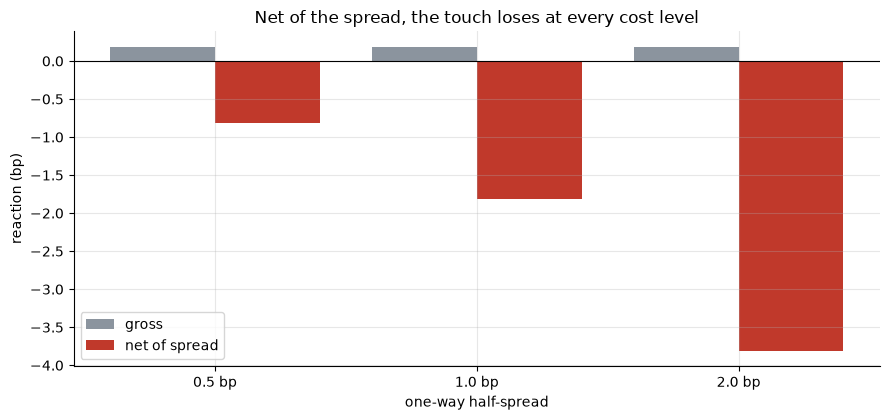

half-spread 0.5 bp: gross=+0.19bp  net=-0.81bp
half-spread 1.0 bp: gross=+0.19bp  net=-1.81bp
half-spread 2.0 bp: gross=+0.19bp  net=-3.81bp


In [5]:
cs = [c for c,_,_ in R['cost']]; gross = [g for _,g,_ in R['cost']]; net = [n for _,_,n in R['cost']]
x = np.arange(len(cs))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, gross, .4, color=GREY, label='gross'); ax.bar(x+.2, net, .4, color=RED, label='net of spread')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{c} bp' for c in cs])
ax.set_xlabel('one-way half-spread'); ax.set_ylabel('reaction (bp)')
ax.set_title('Net of the spread, the touch loses at every cost level'); ax.legend()
plt.tight_layout(); plt.show()
for c,g,n in R['cost']: print(f'half-spread {c} bp: gross={g:+.2f}bp  net={n:+.2f}bp')

> 💡 In plain words: the gross reaction is **+0.19 bp**; even a half-bp half-spread (best case on SPY) nets **-0.81 bp**. The edge is smaller than the cost of touching it — the canonical death of an intraday level.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic intraday tape where we **plant** a known AVWAP magnet: with **zero** magnet the HAC *t* must stay near zero (no false positive); with a real planted magnet it must light up. Both hold — so the flat real-tape result is a genuine "no," not a broken detector.

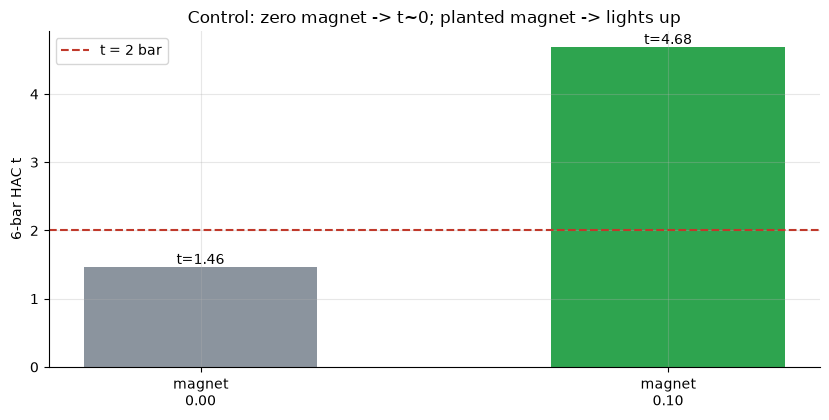

magnet=+0.00: n=488 av=+1.04bp t_one=+1.03 t_hac=+1.46 win=54%
magnet=+0.10: n=745 av=+2.23bp t_one=+3.39 t_hac=+4.68 win=56%


In [6]:
res = []
for m in (0.0, 0.10):
    px, _ = data.synthetic_panel(magnet=m, seed=442)
    av = st.avwap_reactions(st.session_avwap(px), 6)
    res.append((m, len(av), av.mean()*1e4, st.ttest_vs_zero(av), st.hac_t(av), (av>0).mean()*100))
labels = [f'magnet\n{m:.2f}' for m,_,_,_,_,_ in res]; tvals = [r[4] for r in res]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('6-bar HAC t'); ax.set_title('Control: zero magnet -> t~0; planted magnet -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for m,k,a,t1,th,w in res: print(f'magnet={m:+.2f}: n={k} av={a:+.2f}bp t_one={t1:+.2f} t_hac={th:+.2f} win={w:.0f}%')

> 💡 In plain words: with **no** planted magnet the control sits at HAC *t* = 1.46 (noise can't fake it); a planted magnet reaches HAC *t* = 4.68. The detector works — it simply finds **nothing** on the real tape, which is the honest answer.

## 5 · The verdict

- **Signal `NONE`** — post-touch reversion **+0.19 bp** at 6 bars (one-sample **t = 0.19**, **HAC t = 0.29**), flat across 1–12 bars, win-rate 50%. Nowhere near **t ≥ 2** on the most liquid tape there is. Carries an explicit **short-span** caveat (~59 sessions).
- **Tradability `MIRAGE`** — net of a 1-bp half-spread × 2 legs the reaction is **-1.81 bp** and negative at every cost level. The gross reaction is thinner than the spread; nothing to scale.
- **Price magnet? `NOT SUPPORTED`** — a **random** level reacts **+0.35 bp** (Welch **t = -0.16**) and matches/beats AVWAP **71%** of the time (placebo **p = 0.711**). The AVWAP is an average, not a magnet.

## 6 · Could you trade it? — no, and here's the one number

The whole tradability case in one frame: the net reaction by horizon, with break-even. It never lifts above zero.

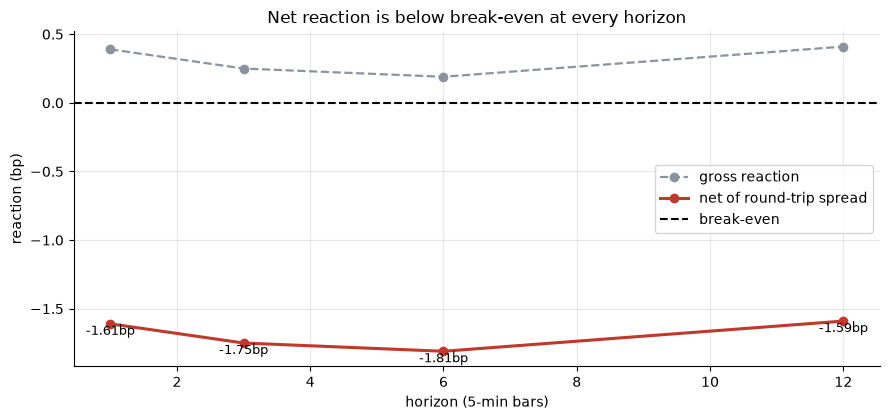

net reaction by horizon (bp): {'1b': -1.61, '3b': -1.75, '6b': -1.81, '12b': -1.59}


In [7]:
hs = [1, 3, 6, 12]
gross = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
net = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, gross, 'o--', c=GREY, lw=1.6, label='gross reaction')
ax.plot(hs, net, 'o-', c=RED, lw=2.2, label='net of round-trip spread')
ax.axhline(0, c='k', ls='--', label='break-even')
for h,v in zip(hs,net): ax.annotate(f'{v:+.2f}bp',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (5-min bars)'); ax.set_ylabel('reaction (bp)')
ax.set_title('Net reaction is below break-even at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('net reaction by horizon (bp):', {f'{h}b': v for h,v in zip(hs,net)})

> 💡 In plain words: the red (net) line never crosses zero. There's no horizon, no name, and no anchor (we checked the cleanest one) where fading the AVWAP touch makes money after the spread. **MIRAGE**, on the friendliest possible tape.

## 7 · Going further

- **Other anchors.** `session_avwap` anchors to the open; swap in an earnings-gap or swing-high anchor and rerun — the believers' hand-picked anchors are the part most exposed to selection, and a rule-based version is flat.
- **The discriminator generalises.** The *random-level placebo* is the right test for any "price respects level X" claim (round numbers, prior-day high, moving averages). A level only matters if it beats a line drawn at random.
- **VWAP's real job.** As an *execution* benchmark (TWAP/VWAP slicing; Berkowitz, Logue & Noser 1988) VWAP is genuinely useful — the failure here is the *forecasting* claim, not the benchmark.

*The reproducible core is offline and deterministic; methods and sources in [`docs/references.md`](../docs/references.md), frozen numbers in [`docs/results.md`](../docs/results.md).*